In [ ]:
import pdfplumber
from pathlib import Path
from sentence_transformers import SentenceTransformer
from tqdm import tqdm

In [6]:
PDF_FOLDER = Path("data/pdfs")
CHROMA_PATH = Path("chroma_db") 
CHROMA_COLLECTION = "alzheimer_papers"
nlp_model = SentenceTransformer("NeuML/pubmedbert-base-embeddings")
pdf_paths = sorted(PDF_FOLDER.glob('*.pdf'))

In [11]:
import pandas as pd
df_v1 = pd.read_csv('rag_evaluation_vsearch_funcscore.csv')
mean_latency_v1 = df_v1['latency_seconds'].mean()
df_v2 = pd.read_csv('rag_evaluation_hsearch_funcscore.csv')
mean_latency_v2 = df_v2['latency_seconds'].mean()
df_v3 = pd.read_csv('rag_evaluation_hsearch_funcscore_hyde.csv')
mean_latency_v3 = df_v3['latency_seconds'].mean()
print(f"Mean lattency v1: {mean_latency_v1}")
print(f"Mean lattency v2: {mean_latency_v2}")
print(f"Mean lattency v3: {mean_latency_v3}")

Mean lattency v1: 9.80488974169681
Mean lattency v2: 11.254631067577161
Mean lattency v3: 14.792535643828543


# Анализ ответов

In [ ]:
import pandas as pd
import os

file_paths = [
    "rag_evaluation_v1_final_with_avg.csv", #JUST VECTOR SEARCH + EXTRA_SCORE
    "rag_evaluation_v2_final_with_avg.csv", #HYBRID SEARCH + EXTRA_SCORE
    "rag_evaluation_v3_final_with_avg.csv" #HYBRID SEARCH + HYDE
]

summary_rows = []

for i, file_path in enumerate(file_paths, 1):
    if os.path.exists(file_path):
        df = pd.read_csv(file_path)
        last_row = df.iloc[-1].copy()  
        last_row['version'] = f'v{i}'  
        summary_rows.append(last_row)
    else:
        print(f"Warning: {file_path} not found")

if summary_rows:
    final_summary_df = pd.DataFrame(summary_rows)
    
    cols = ['version'] + [col for col in final_summary_df.columns if col != 'version']
    final_summary_df = final_summary_df[cols]

final_summary_df

# Экстракция текста PDF

In [ ]:
def extract_pdf_text(pdf_path: Path) -> dict:
    parts = []
    
    with pdfplumber.open(str(pdf_path)) as pdf:
        n_pages = len(pdf.pages)
        
        for page in pdf.pages:
            t = page.extract_text() or ''
            if t:
                parts.append(t)
    
    full_text = '\n\n'.join(parts).strip()
        
    return {
        'source': pdf_path.name,
        'n_pages': n_pages,
        'text': full_text
    }

In [ ]:
records = []

for p in tqdm(pdf_paths, desc='Extracting PDFs'):
    rec = extract_pdf_text(p)
    records.append(rec)

Extracting PDFs: 100%|██████████| 24/24 [00:55<00:00,  2.31s/it]


# Experiment with using NLTK + WordCloud for EDA (unsuccessfully)

In [ ]:
import pandas as pd
import re
from collections import Counter
import nltk
from nltk import pos_tag, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
import matplotlib.pyplot as plt
from wordcloud import WordCloud

nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger_eng')

df = pd.DataFrame(records)
df['year'] = df['source'].str.extract(r'(\d{4})', expand=False).astype(float)  

lemmatizer = WordNetLemmatizer()
stop_eng = set(stopwords.words('english'))
stop_eng.update(['alzheimer', 'disease', 'ad', 'study', 'patient', 'result', 'fig', 'figure'])

def scientific_clean_v2(text, lemma=True, keep_compounds=True, min_len=3):
    """
    Enhanced text cleaning version for scientific texts about Alzheimer targets

    Parameters:
        keep_compounds : bool - preserve compound terms with hyphens (amyloid-beta, p-tau, etc.)
        min_len        : minimum token length after cleaning
    """

    text = re.sub(r'https?://\S+|www\.\S+', '', text)               
    text = re.sub(r'doi:\S+|pmid:\S+|PMID:\S+', '', text)           
    text = re.sub(r'\[[\d,\s]+\]|\(\d+\)|\{\d+\}', '', text)      
    text = re.sub(r'[\u2009–\u2013\u2014]', '-', text)           
    
    text = text.lower()
    
    if keep_compounds:
        text = re.sub(r'[^a-z\s\-]', ' ', text)
        text = re.sub(r'-+', '-', text)
        text = re.sub(r'\s+-\s+|\s+-\b|\b-\s+', ' ', text)
    else:
        text = re.sub(r'[^a-z\s]', ' ', text)
    
    tokens = word_tokenize(text)

    tokens = [
        t for t in tokens
        if len(t) >= min_len
        and not t.isdigit()            
        and not (t.startswith('-') and len(t) < 5)  
    ]
    
    extended_stops = stop_eng | {
        'et', 'al', 'fig', 'figs', 'table', 'tables', 'supp', 'supplemental',
        'section', 'chapter', 'doi', 'pmid', 'ref', 'refs', 'also', 'thus',
        'however', 'therefore', 'moreover', 'furthermore', 'conclusion',
        'background', 'method', 'methods', 'result', 'results', 'discussion'
    }
    
    tokens = [t for t in tokens if t not in extended_stops]
    
    if lemma:
        tagged = pos_tag(tokens)
        tokens = []
        for word, tag in tagged:
            wntag = tag[0].lower()
            wntag = wntag if wntag in ['a', 'r', 'n', 'v'] else 'n'
            lemma_word = lemmatizer.lemmatize(word, wntag)
            if len(lemma_word) > 4 or lemma_word.upper() == lemma_word:
                tokens.append(lemma_word)
            else:
                tokens.append(word) 
    
    return tokens

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


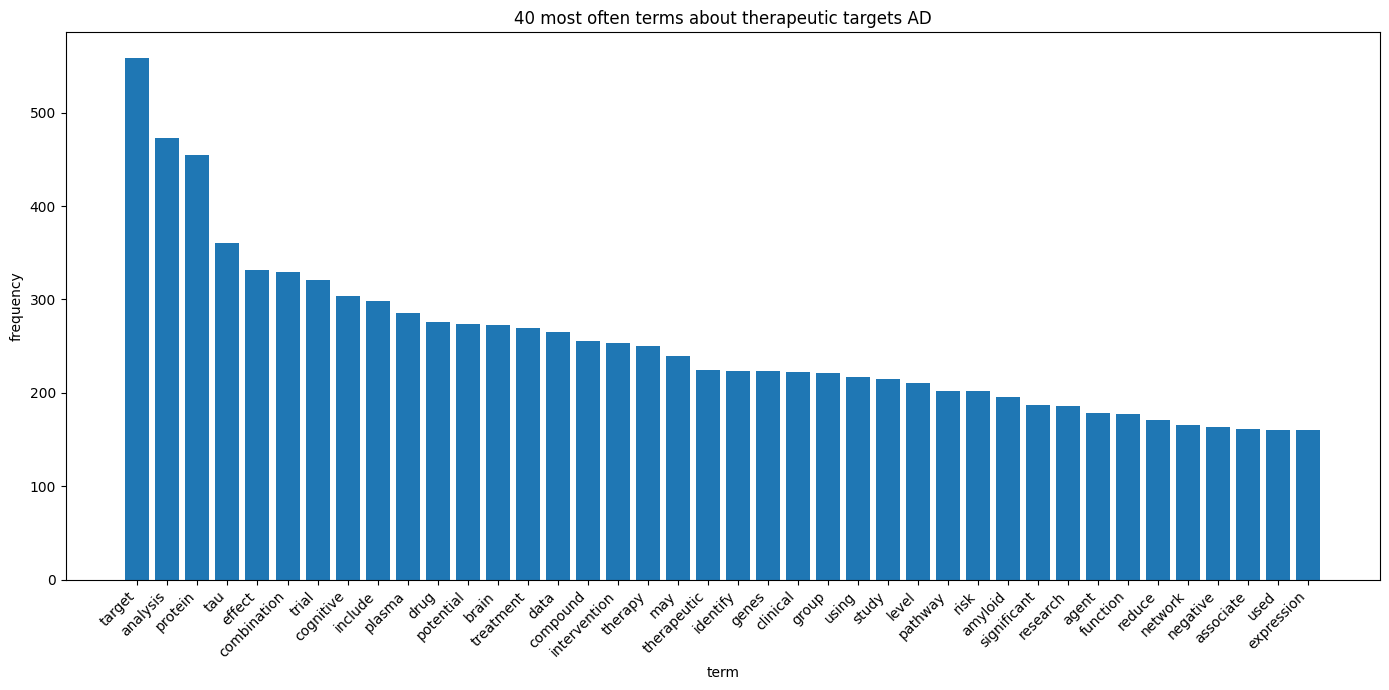

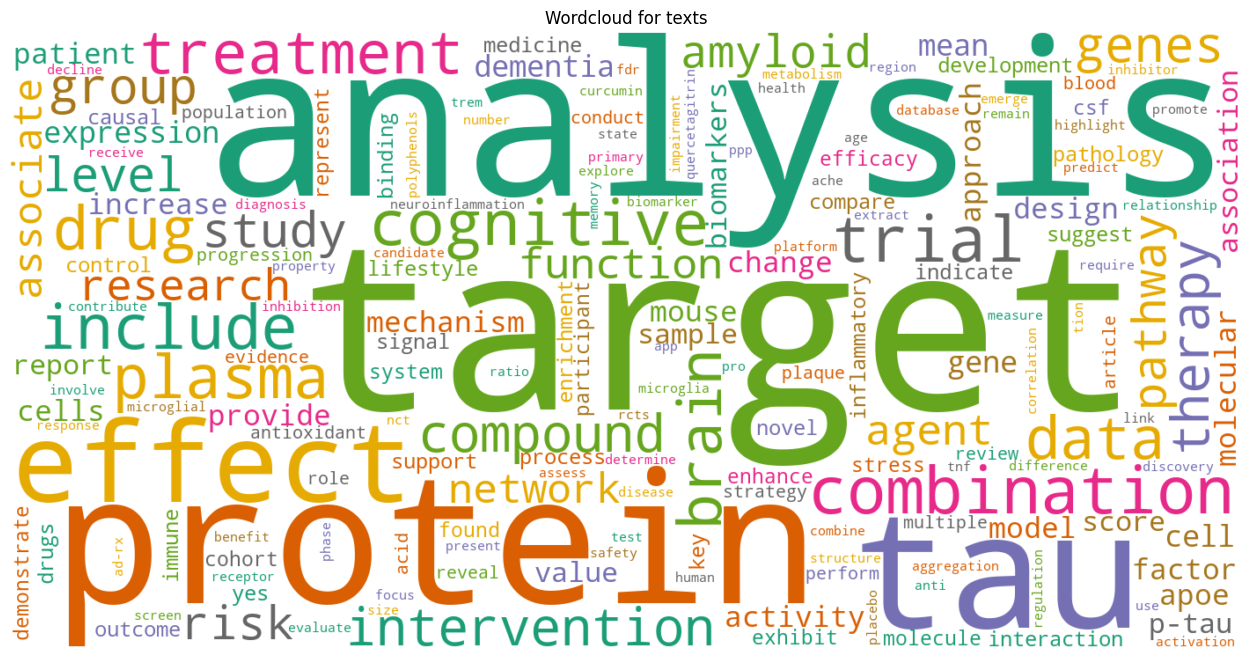

Top-25 TF-IDF:
tau                                 0.0763
target                              0.0652
protein                             0.0621
analysis                            0.0506
brain                               0.0462
plasma                              0.0445
compound                            0.0437
trial                               0.0378
combination                         0.0375
cognitive                           0.0349
effect                              0.0337
genes                               0.0333
drug                                0.0322
data                                0.0318
causal                              0.0307
include                             0.0293
amyloid                             0.0288
potential                           0.0287
apoe                                0.0283
clinical                            0.0279
intervention                        0.0262
risk                                0.0260
identify                            0.0

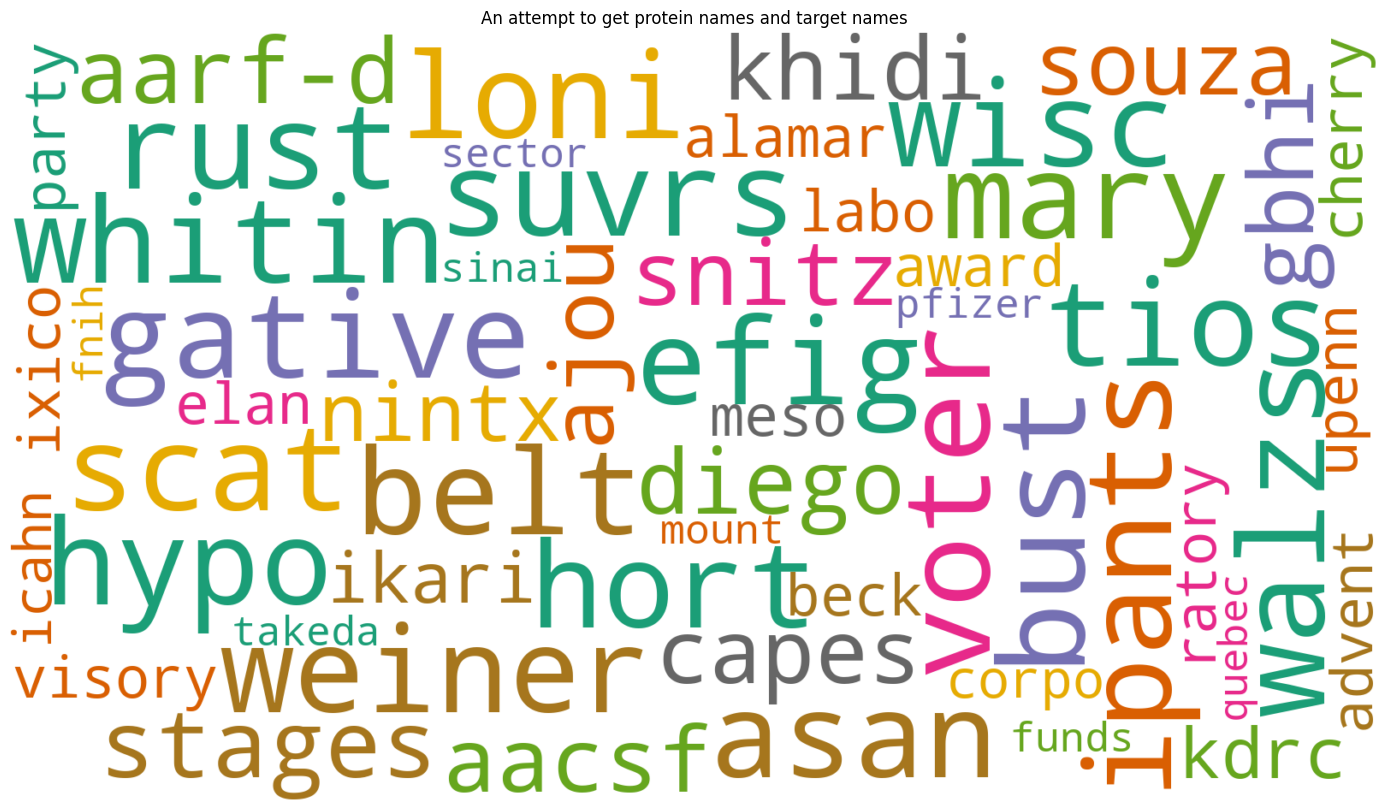

In [74]:
df['tokens']     = df['text'].apply(scientific_clean_v2)
df['clean_text'] = df['tokens'].apply(lambda x: ' '.join(x))

all_words = [w for tokens in df['tokens'] for w in tokens]
freq = Counter(all_words)

top40 = freq.most_common(40)
words, counts = zip(*top40)

plt.figure(figsize=(14, 7))
plt.bar(words, counts)
plt.title("40 most often terms about therapeutic targets AD")
plt.xlabel("term")
plt.ylabel("frequency")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

###

nouns = [w for tokens in df['tokens'] for w in tokens 
         if pos_tag([w])[0][1] in ['NN','NNS','NNP','NNPS']]
wc = WordCloud(width=1400, height=700, background_color='white', 
               max_words=180, colormap='Dark2').generate_from_frequencies(Counter(nouns))
plt.figure(figsize=(16,8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Wordcloud for texts")
plt.show()

tfidf = TfidfVectorizer(max_features=6000, ngram_range=(1,3), 
                        stop_words=list(stop_eng))
tfidf_matrix = tfidf.fit_transform(df['clean_text'])

feature_names = tfidf.get_feature_names_out()
mean_tfidf = tfidf_matrix.mean(axis=0).A1
top_idx = mean_tfidf.argsort()[-25:][::-1]
print("Top-25 TF-IDF:")
for i in top_idx:
    print(f"{feature_names[i]:<35} {mean_tfidf[i]:.4f}")

###

noise_words = {word for word, _ in Counter(nouns).most_common(12000)} 

important_nouns = [
    word for word in nouns
    if word.lower() not in noise_words
    and 4 <= len(word) <= 6  #most likely, the names of proteins and drugs will be between 3 and 5 letters, so we add a condition with 'and'
]

noun_freq = Counter(important_nouns)

wc = WordCloud(
    width=1600,
    height=900,
    background_color='white',
    max_words=180,
    min_font_size=10,
    max_font_size=140,
    colormap='Dark2',
    prefer_horizontal=0.9
).generate_from_frequencies(noun_freq)

plt.figure(figsize=(18, 10))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("An attempt to get protein names and target names")
plt.show()




# Experiment with using extracted text from PDFs using DeepSeek-OCR + OpenRouter + Prompt-Engineering for EDA (unsuccessfully)

In [ ]:
from openai import OpenAI
import os

client = OpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.getenv('OPENROUTER_API_KEY')
)

def extract_targets(text: str) -> list[str]:
    response = client.chat.completions.create(
        model="openai/gpt-oss-120b:free",
        messages=[
            {
                "role": "system",
                "content": """You are an expert biomedical NER system specialized in Alzheimer's disease research.
Extract ONLY protein names, gene names, and therapeutic targets (including antibodies, small molecules, etc.).
Rules:
- Return ONLY a bullet list
- Use exact original spelling from text
- Do not add explanations, introductions or comments
- If nothing found → return empty list"""
            },
            {
                "role": "user",
                "content": f"Text excerpt:\n\n{text[:45000]}"   
            }
        ],
        temperature=0.0,
        max_tokens=300,
    )
    
    raw = response.choices[0].message.content.strip()
    #items = [line.strip('- *').strip() for line in raw.split('\n') if line.strip().startswith(('-','*'))]
    return raw

In [92]:
extract_targets(
    """

| Table 1 | MR results for variables significantly associated with AD after FDR correction |
|---|---|
| Tissue    | Protein    | SNP    | Effect allele | Method    | OR (95% CI)    | \( P_{FDR} \) value | \( R^2 \) | F statistics | Target level |
|---|---|---|---|---|---|---|---|---|---|
| Plasma    | PILRA isoform    | rs1859788    | A    | Wald ratio    | 0.955 (0.940, 0.971)    | 1.13E-05    | 0.040    | 1479658    | Tier 1    |
|    | FDF03-M14    |    |    |    |    |    |    |    |    |
| Plasma    | PILRA isoform    | rs1859788    | A    | Wald ratio    | 0.955 (0.940, 0.971)    | 1.13E-05    | 0.040    | 1479658    | Tier 1    |
|    | FDF03-deltaTM    |    |    |    |    |    |    |    |    |
| Plasma    | GBN    | rs5848    | T    | Wald ratio    | 0.792 (0.716, 0.875)    | 1.32E-03    | 0.015    | 539812    | Tier 1    |
| Plasma    | ACE    | rs4363    | G    | Wald ratio    | 0.930 (0.900, 0.960)    | 1.34E-03    | 0.040    | 1479658    | Tier 1    |
| Plasma    | TIMD3    | rs6873659    | A    | Wald ratio    | 0.909 (0.874, 0.946)    | 7.28E-04    | 0.040    | 1479658    | Tier 1    |
| Plasma    | TREM2    | rs75932628    | T    | Wald ratio    | 0.656 (0.583, 0.739)    | 2.14E-09    | 0.033    | 1213484    | Tier 1    |
| Plasma    | ACADV    | rs507506    | A    | Wald ratio    | 2.465 (1.665, 3.647)    | 1.34E-03    | 0.001    | 37.050    | Tier 3    |
| Plasma    | OMGP    | rs12449302    | C    | Wald ratio    | 0.615 (0.482, 0.786)    | 1.49E-02    | 0.003    | 118128    | Tier 3    |
| Plasma    | BIN1    | rs35103166    | C    | Wald ratio    | 1.870 (1.599, 2.188)    | 7.34E-12    | 0.007    | 24.351    | Tier 5    |
| CSF    | Siglec-3    | rs12459419    | T    | Wald ratio    | 1.511 (1.325, 1.723)    | 4.78E-08    | 0.373    | 496096    | Tier 2    |
| CSF    | TIMD3    | rs116462788    | T    | Wald ratio    | 2.932 (1.689, 5.093)    | 6.08E-03    | 0.039    | 33.435    | Tier 3    |
| CSF    | Siglec-7    | rs2673908    | A    | Wald ratio    | 2.477 (1.511, 4.063)    | 8.92E-03    | 0.040    | 34.856    | Tier 3    |
| CSF    | Siglec-9    | rs2673908    | A    | Wald ratio    | 1.033 (1.015, 1.051)    | 8.92E-03    | 0.604    | 1272118    | Tier 3    |
| Brain    | APOE2    | rs769449    | G    | Wald ratio    | 3.62E-05 (2.79E-05, 4.69E-05)    | 4.76E-32    | 0.166    | 75.227    | Tier 2    |

Brain    | IDUA    | rs6599390    | G    | Wald ratio    | 0.647 (0.492, 0.850)    | 1.90E-02    | 0.175    | 80.081    | Tier 4    |

Abbreviations: AD Alzheimer’s disease, CI Confidence interval, CSF Cerebrospinal fluid, MR Mendelian randomization, OR Odds ratio, SNP Single-nucleotide polymorphism (cis-acting in this research)

Liu et al. Alzheimer’s Research & Therapy (2025) 17:258 Page 7 of 16

Table 2 Summary data for sensitivity analyses and external validation results related to possible causal proteins

| Tissue    | Protein    | SNP    | Bidirectional MR | Steiger filtering | Colocalization PPH4 | P value (SMR) | HEIDI test | Validation |
|---|---|---|---|---|---|---|---|---|
| Plasma    | PILRA isoform    | rs1859788    | −0.002 (−0.020, 0.015) | Passed (1.14E-268)    | 0.993    | 6.79E-07   | 0.254    | ARIC_INTERVAL, Fimgen, IGAP    |
| Plasma    | FDF03-M14    |    |    |    |    |    |    |    |
| Plasma    | PILRA isoform    | rs1859788    | 0.000 (−0.018, 0.018) | Passed (1.14E-268)    | 0.993    | 6.79E-07   | 0.254    | ARIC_INTERVAL, Fimgen, IGAP    |
| Plasma    | FDF03-deltaTM    |    |    |    |    |    |    |    |
| Plasma    | GRN    | rs5848    | −0.019 (−0.045, 0.007) | Passed (5.06E-97)    | 0.991    | 8.05E-06   | 0.264    | ARIC_INTERVAL, Fimgen, IGAP    |
| Plasma    | ACE    | rs4363    | −0.003 (−0.022, 0.017) | Passed (2.88E-273)    | 0.977    | 7.42E-06   | 0.674    | ARIC_INTERVAL, Fimgen, IGAP    |
| Plasma    | TIMD3    | rs6873659    | −0.091 (−0.368, 0.186) | Passed (2.74E-272)    | 0.874    | 3.33E-04   | 0.706    | ARIC_INTERVAL, Fimgen, IGAP    |
| Plasma    | ACADV    | rs507506    | 0.003 (−0.017, 0.022) | Passed (5.64E-06)    | 0.977    | 2.91E-04   | 0.602    | IGAP    |
| Plasma    | OMGP    | rs12449302    | −0.010 (−0.041, 0.021) | Passed (1.47E-20)    | 0.929    | 2.55E-04   | 0.913    | IGAP    |
| Plasma    | BIN1    | rs35103166    | 0.009 (−0.037, 0.054) | Passed (1.01E-36)    | 1.48E-24   | 2.69E-12   | 5.04E-07   | ARIC_INTERVAL, Fimgen, IGAP    |
| Plasma    | TREM2    | rs75932628    | −0.150 (−0.395, 0.094) | Passed (1.43E-213)    | 0.922    | 2.21E-08   | 0.165    | ARIC_IGAP    |
| CSF    | TIMD3    | rs11646278    | −0.013 (−0.125, 0.098) | Passed (2.72E-08)    | 0.853    | 1.43E-03   | 0.572    | IGAP    |
| CSF    | Siglec-3    | rs12459419    | 0.019 (−0.034, 0.072) | Passed (1.92E-92)    | 0.999    | 2.79E-09   | 2.59E-03   | Fimgen, IGAP    |
| CSF    | Siglec-7    | rs2673908    | −0.023 (−0.059, 0.013) | Passed (1.28E-08)    | 0.002    | 1.64E-03   | 0.375    | Fimgen    |
| CSF    | Siglec-9    | rs2673908    | 0.010 (−0.268, 0.288) | Passed (4.72E-202)    | 0.002    | 2.69E-04   | 0.375    | Fimgen    |
| Brain    | APOE2    | rs769449    | 0.041 (−0.073, 0.154) | Passed (5.09E-09)    | 1.000    | 5.52E-18   | 7.60E-05   | Fimgen, IGAP    |
| Brain    | IDUA    | rs6599390    | 0.044 (−0.019, 0.107) | Passed (7.47E-18)    | 0.296    | 3.22E-03   | 0.339    | NA    |

"""
)

<>:6: SyntaxWarning: invalid escape sequence '\('
<>:6: SyntaxWarning: invalid escape sequence '\('
C:\Users\User\AppData\Local\Temp\ipykernel_13100\1268671332.py:6: SyntaxWarning: invalid escape sequence '\('
  | Tissue    | Protein    | SNP    | Effect allele | Method    | OR (95% CI)    | \( P_{FDR} \) value | \( R^2 \) | F statistics | Target level |


''

# Experiment with using DeepSeek-OCR + DeepSeek-V3.2 for EDA and solving NER problem (successfully)

**Pipeline**

1. Upload article in PDF-format into `chat.deepseek.com`

2. Give it a prompt:

>You are an expert biomedical named entity recognition system and fact-checker specialized in Alzheimer's disease research, neuroscience, and pharmacology.
>
>Task:
>Read the entire provided text and extract ONLY those named entities that are meaningfully studied, investigated, targeted, modulated, tested, or discussed as potential therapeutic agents/targets in THIS SPECIFIC ARTICLE.
>
>Entity types to consider:
>- Specific protein names and gene names
>- Therapeutic targets (specific proteins, pathways, receptors, enzymes being modulated)
>- Drug names, therapeutic agents, compounds (small molecules, monoclonal antibodies, ASOs, gene therapies, vaccines, etc.)
>- Biomarkers used in AD context
>- Clinical trial identifiers (NCTxxxxxxxx) when clearly associated with a drug or target
>
>Important filtering rules — apply very strictly:
>
>1. Include ONLY entities that are:
>   - The main focus of the study
>   - Actively investigated or modulated in the article
>   - Presented as potential therapeutic targets or candidates
>   - Tested, evaluated, or discussed in detail (mechanisms, efficacy, safety, etc.)
>
>2. EXCLUDE entities that are:
>   - Mentioned only in passing / background / historical context
>   - General knowledge / well-known facts not specifically studied here
>   - Used only as comparators, controls, or reference points
>  - Not central to the main scientific contribution of THIS paper
>
>Additional strict rules:
>- Preserve exact original spelling, capitalization and punctuation as they appear in the text
>- Do NOT include generic terms like "protein", "gene", "target", "drug", etc. unless part of proper name
>- Do NOT deduplicate — include every relevant occurrence as it appears
>- Perform basic fact-checking: remove obvious parsing/OCR errors and implausible entities
>- If nothing meets the strict criteria → return exactly: ['No central entities meaningfully studied in this article']
>
>Output format — EXTREMELY JSON:
>Return ONLY JSON-TYPE TEXT: — Cleaned title derived from filename
>Nothing else is allowed: no explanations, no comments, no markdown, no introductory text.
>
>Schema:
>{
>  "article_title": "Cleaned title derived from filename or empty string",
>  "entities": ["Entity1", "Entity2", ...]    // array of strings, may be empty
>}
>
>Correct examples:
>{"article_title": "131915_2025_Atr", "entities": ["lecanemab", "donanemab", "amyloid-beta", "BACE1"]}
>{"article_title": "TREM2 Agonism Therapeutic Strategy", "entities": ["TREM2 agonist", "AL002", "p-tau181", "NCT04592835"]}
>{"article_title": "", "entities": []}
>{"article_title": "2024 Alzheimer Pipeline Review", "entities": []}

3. Make a file `<pdf-filename>.json` in `BIOCAD\data_processing\data\entities`

**Result**

Following Named Entity Recognition (NER) processing of PDF articles, JSON files were generated for each document containing:

- The article title (derived from the filename)

- An array of extracted biomedical entities (therapeutic targets, drug names, biomarkers, etc.)

- Output format: {"article_title": "filename", "entities": ["entity1", "entity2", ...]}

One article is indirectly related to the topic of Alzheimer's disease

# Небольшая ручная чистка текстов

In [26]:
import json

def clean_repeated_patterns(text):
    pattern = r'\bFDR\b(?:\s+FDR\b){3,}'
    cleaned_text = re.sub(pattern, '', text)
    cleaned_text = re.sub(r' +', ' ', cleaned_text).strip()
    return cleaned_text

with open('dataprep/data/merged/with_llm/all_merged_llm.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

if data and 'full_text' in data[0]:
    data[0]['full_text'] = clean_repeated_patterns(data[0]['full_text'])

with open('dataprep/data/merged/with_llm/all_merged_llm.json', 'w', encoding='utf-8') as f:
    json.dump(data, f, ensure_ascii=False, indent=2)

print("First article has been cleaned successfully!")

### конечная проверка чистки текста была проведена с помощью gemini-3-pro-preview: на вход модели подавался битый текст, на выходе восстановленный текст; качество генерации оценивалось человеком

First article has been cleaned successfully!
